## Loading and Pre-Cleaning

Import libraries and modules

In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

Load dataset and examine structure

In [37]:
url = "https://raw.githubusercontent.com/UmarHMoh/COMP3608-LOANS-PROJECT/refs/heads/datasets-Load_Default.csv/data/Loan_Default.csv"

#df=pd.read_csv("Loan_Default.csv")
df = pd.read_csv(url, encoding="latin1", sep=",")
print(df.shape)
print(df.head())

(148670, 34)
      ID  year loan_limit             Gender approv_in_adv loan_type  \
0  24890  2019         cf  Sex Not Available         nopre     type1   
1  24891  2019         cf               Male         nopre     type2   
2  24892  2019         cf               Male           pre     type1   
3  24893  2019         cf               Male         nopre     type1   
4  24894  2019         cf              Joint           pre     type1   

  loan_purpose Credit_Worthiness open_credit business_or_commercial  ...  \
0           p1                l1        nopc                  nob/c  ...   
1           p1                l1        nopc                    b/c  ...   
2           p1                l1        nopc                  nob/c  ...   
3           p4                l1        nopc                  nob/c  ...   
4           p1                l1        nopc                  nob/c  ...   

   credit_type  Credit_Score  co-applicant_credit_type    age  \
0          EXP           758    

We collect pre-cleaning data and export to Excel which will help to inform decision making as it relates to cleaning the dataset.

In [38]:
summary=pd.DataFrame()
# All variables
summary["Variable Name"]=df.columns
summary["Data Type"]=df.dtypes.values
summary["No. Unique Values"] = df.nunique().values
summary["Sample Values"] = summary["Variable Name"].map(
    lambda col: ", ".join(map(str, df[col].dropna().unique()[:5]))
)
summary["Missing %"] = summary["Variable Name"].map(df.isnull().mean() * 100)
# Categorical columns
cat_cols = df.select_dtypes(include=['object', 'string']).columns
summary["Top Category Frequency (%)"] = None
for col in cat_cols:
    top_freq = df[col].value_counts(normalize=True).iloc[0] * 100
    summary.loc[summary["Variable Name"] == col, "Top Category Frequency (%)"] = top_freq
#Numerical Columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
summary["Num: Std"] = summary["Variable Name"].map(df.std(numeric_only=True))
summary["Num: Min"] = summary["Variable Name"].map(df.min(numeric_only=True))
summary["Num: Max"] = summary["Variable Name"].map(df.max(numeric_only=True))
correlations = df.corr(numeric_only=True)["Status"]
summary["Correlation with Status"] = summary["Variable Name"].map(correlations)
#print(summary)
#summary.to_excel("data_summary.xlsx", index=False)

## Data Cleaning & Preparation

Drop columns with low variability; Define target y and features matrix X; For selected variables with missing values, we add missing indicators column to X

In [39]:
df=df.drop(columns=["Security_Type","total_units","Secured_by","construction_type","year","ID"])
df=df.drop(columns=["Interest_rate_spread"]) #excluded due to perfect performance-data leakage
y = df["Status"]
X = df.drop("Status", axis=1)
#X["interest_missing"] = X["rate_of_interest"].isnull().astype(int) #exclude due to perfect performance
X["property_value_missing"] = X["property_value"].isnull().astype(int)
X["income_missing"] = X["income"].isnull().astype(int)
X["dtir1_missing"] = X["dtir1"].isnull().astype(int)

We split X and y into train and test sets. We define numerical columns and categorical columns of X. 

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

C:\Users\andre\AppData\Local\Temp\ipykernel_43172\3481788256.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object"]).columns


Perform imputation for missing values

In [41]:
# Numeric
num_imputer = SimpleImputer(strategy="median")
num_imputer.fit(X_train[num_cols])
X_train[num_cols] = num_imputer.transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])
# Categorical
cat_imputer = SimpleImputer(strategy="most_frequent")
cat_imputer.fit(X_train[cat_cols])
X_train[cat_cols] = cat_imputer.transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

Encoding of categorical variables. (For decision trees-encoding is optional, for logistic regression and KNN, encoding is very critical)

In [42]:
#For encoding of categorical variables, we split into nominal and ordinal
cat_ord_cols = ["age"]
cat_nom_cols = [col for col in cat_cols if col not in cat_ord_cols]

#One Hot Encoding of nominal vars
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
#1. Create arrays captured encoded columns
X_train_nom_encoded = ohe.fit_transform(X_train[cat_nom_cols])
X_test_nom_encoded = ohe.transform(X_test[cat_nom_cols])
#2. Convert arrays to dataframes
train_nom_df = pd.DataFrame(X_train_nom_encoded, columns=ohe.get_feature_names_out(cat_nom_cols), index=X_train.index)
test_nom_df = pd.DataFrame(X_test_nom_encoded, columns=ohe.get_feature_names_out(cat_nom_cols), index=X_test.index)
#3. Drop original nominal columns from the DFs
X_train = X_train.drop(columns=cat_nom_cols)
X_test = X_test.drop(columns=cat_nom_cols)
#4. Add in the encoded columns
X_train = pd.concat([X_train, train_nom_df], axis=1)
X_test = pd.concat([X_test, test_nom_df], axis=1)
#will now have encoded nominal variables

#Ordinal Encoding
age_order = [['<25', '25-34', '35-44', '45-54', '55-64','65-74','>74']]
#the unique values of X_train["age"] after imputation were printed to populate this list
ord_encoder = OrdinalEncoder(categories=age_order)
X_train[cat_ord_cols] = ord_encoder.fit_transform(X_train[cat_ord_cols]) #reassigns to X_train ordinal columns
X_test[cat_ord_cols] = ord_encoder.transform(X_test[cat_ord_cols]) #reassigns to X_test ordinal columns

We now write code to scale the numeric variables. Many models rely on distances and gradients and having one feature that has possibly larger values will lead to its dominance in the model and erroneous modelling. (For decision trees-scaling is optional, for logistic regression and KNN, scaling is very critical). It is important that we exclude the binary missing indicators columns from num_cols as they should not be scaled. 

In [43]:
scaler = StandardScaler()
#Note that num_cols excludes the OHE columns that were added but includes missing indicator columns which must be removed
indicator_cols = [
    "interest_missing",
    "property_value_missing",
    "income_missing",
    "dtir1_missing"
]
num_cols = [col for col in num_cols if col not in indicator_cols]
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

We now have X_train, X_test, y_train, y_test which are ready to be passed into our models.

## Algorithm Implementations

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

### Logistic Regression

[[22111   295]
 [ 3475  3853]]


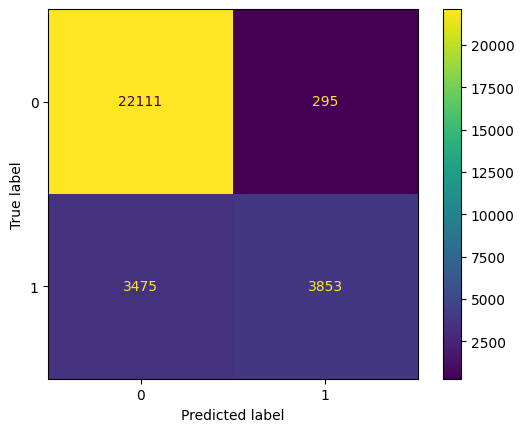

              precision    recall  f1-score   support

           0       0.86      0.99      0.92     22406
           1       0.93      0.53      0.67      7328

    accuracy                           0.87     29734
   macro avg       0.90      0.76      0.80     29734
weighted avg       0.88      0.87      0.86     29734



In [45]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()
print(classification_report(y_test, y_pred))

In [46]:
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_reg.coef_[0]
})

print(coef_df.sort_values(by="Coefficient", key=abs, ascending=False))
print(df.groupby("Status")["income"].apply(lambda x: x.isna().mean()))
print(df.groupby("Status")["rate_of_interest"].apply(lambda x: x.isna().mean()))

                               Feature  Coefficient
45                    credit_type_EQUI     4.179605
10              property_value_missing     3.837912
11                      income_missing    -2.483219
38               lump_sum_payment_lpsm     1.399579
43                     credit_type_CIB    -1.310881
12                       dtir1_missing     1.301661
46                     credit_type_EXP    -1.293817
44                    credit_type_CRIF    -1.269365
39           lump_sum_payment_not_lpsm    -1.094037
40                   occupancy_type_ir     0.806765
50   submission_of_application_to_inst     0.797094
34           Neg_ammortization_neg_amm     0.755981
25                     loan_purpose_p2     0.642916
2                      Upfront_charges    -0.578369
8                                  LTV     0.566806
41                   occupancy_type_pr    -0.554013
14                      loan_limit_ncf     0.507304
49  submission_of_application_not_inst    -0.491553
1           

### K-Nearest Neighbour

[[21562   844]
 [ 2236  5092]]


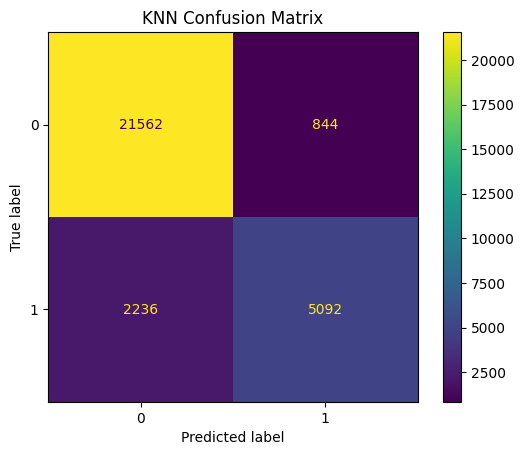


KNN Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.96      0.93     22406
           1       0.86      0.69      0.77      7328

    accuracy                           0.90     29734
   macro avg       0.88      0.83      0.85     29734
weighted avg       0.89      0.90      0.89     29734



In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

cm_knn = confusion_matrix(y_test, y_pred_knn)
print(cm_knn)

ConfusionMatrixDisplay(confusion_matrix=cm_knn).plot()
plt.title("KNN Confusion Matrix")
plt.show()

print("\nKNN Classification Report:\n")
print(classification_report(y_test, y_pred_knn))

### Decision Trees

Decision Tree Confusion Matrix:
 [[22337    69]
 [   87  7241]]


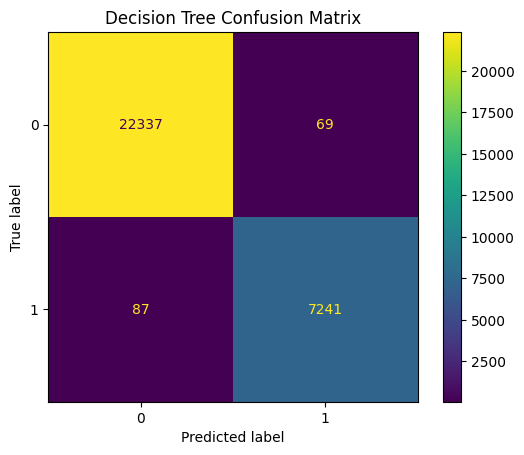


Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22406
           1       0.99      0.99      0.99      7328

    accuracy                           0.99     29734
   macro avg       0.99      0.99      0.99     29734
weighted avg       0.99      0.99      0.99     29734



In [ ]:
tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

cm_tree = confusion_matrix(y_test, y_pred_tree)
print("Decision Tree Confusion Matrix:\n", cm_tree)

ConfusionMatrixDisplay(confusion_matrix=cm_tree).plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

print("\nDecision Tree Classification Report:\n")
print(classification_report(y_test, y_pred_tree))

                               Feature  Importance
2                      Upfront_charges    0.552221
45                    credit_type_EQUI    0.348084
1                     rate_of_interest    0.086914
8                                  LTV    0.002085
6                         Credit_Score    0.001707
5                               income    0.001522
9                                dtir1    0.001236
4                       property_value    0.000989
0                          loan_amount    0.000958
7                                  age    0.000568
3                                 term    0.000408
46                     credit_type_EXP    0.000275
43                     credit_type_CIB    0.000206
48        co-applicant_credit_type_EXP    0.000202
18            Gender_Sex Not Available    0.000183
51                        Region_North    0.000173
53                      Region_central    0.000172
47        co-applicant_credit_type_CIB    0.000163
17                         Gend

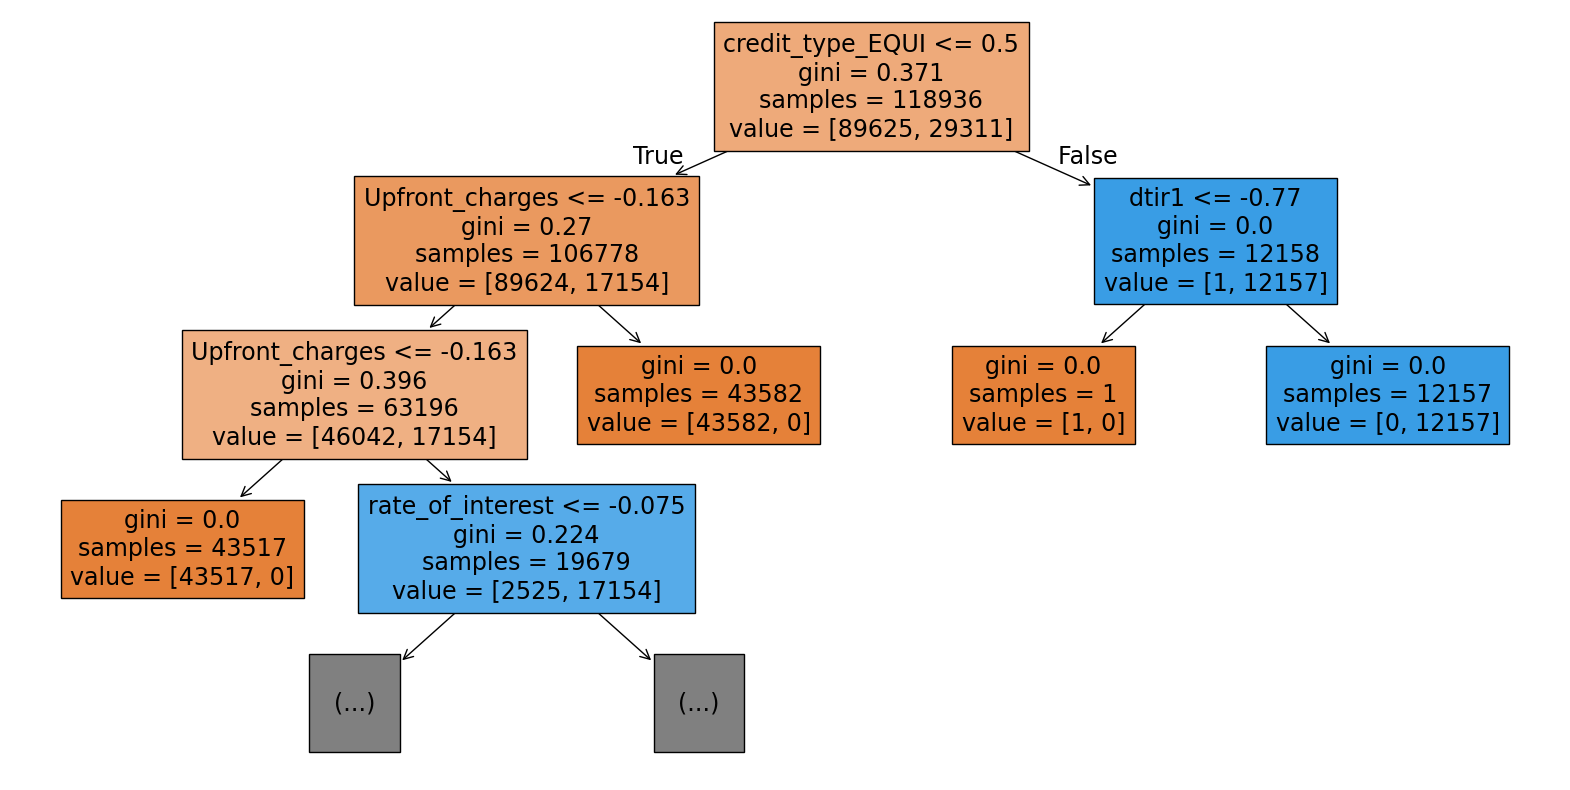

In [59]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": tree.feature_importances_
})

# Sort from most important to least
importance_df = importance_df.sort_values(by="Importance", ascending=False)

print(importance_df)

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(tree, feature_names=X_train.columns, filled=True, max_depth=3)
plt.show()

#df.groupby("Status")["Interest_rate_spread"].mean()

Checking for overfitting

In [60]:
y_train_pred = tree.predict(X_train)

from sklearn.metrics import classification_report

print("TRAINING PERFORMANCE:")
print(classification_report(y_train, y_train_pred))

print("TEST PERFORMANCE:")
print(classification_report(y_test, y_pred_tree))

TRAINING PERFORMANCE:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     89625
           1       1.00      1.00      1.00     29311

    accuracy                           1.00    118936
   macro avg       1.00      1.00      1.00    118936
weighted avg       1.00      1.00      1.00    118936

TEST PERFORMANCE:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22406
           1       0.99      0.99      0.99      7328

    accuracy                           0.99     29734
   macro avg       0.99      0.99      0.99     29734
weighted avg       0.99      0.99      0.99     29734



Checking for leakage

In [61]:
import pandas as pd

duplicates = pd.merge(X_train, X_test, how='inner')
print("Duplicate rows:\n", len(duplicates))

df = pd.concat([X_train, y_train], axis=1)
print(df.corr(numeric_only=True)["Status"].sort_values(ascending=False))

Duplicate rows:
 0
Status                                1.000000
credit_type_EQUI                      0.589986
property_value_missing                0.585733
dtir1_missing                         0.436456
lump_sum_payment_lpsm                 0.182675
Neg_ammortization_neg_amm             0.155712
co-applicant_credit_type_EXP          0.143353
submission_of_application_to_inst     0.122683
loan_type_type2                       0.092219
business_or_commercial_b/c            0.092219
dtir1                                 0.082963
Gender_Sex Not Available              0.054754
loan_limit_ncf                        0.053003
age                                   0.043529
Region_south                          0.040629
LTV                                   0.038541
approv_in_adv_nopre                   0.037853
Credit_Worthiness_l2                  0.034170
loan_purpose_p2                       0.029526
occupancy_type_ir                     0.027703
Gender_Male                           0.0

### Random Forests

Random Forest Confusion Matrix:
 [[22330    76]
 [    0  7328]]


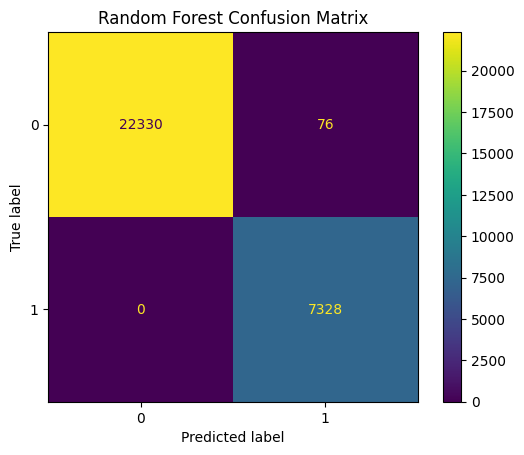


Random Forest Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22406
           1       0.99      1.00      0.99      7328

    accuracy                           1.00     29734
   macro avg       0.99      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734



In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Initialize model
rf = RandomForestClassifier(
    n_estimators=100,      # number of trees
    max_depth=None,        # let trees grow fully (you can tune this)
    random_state=None,
    n_jobs=-1              # use all CPU cores
)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Random Forest Confusion Matrix:\n", cm_rf)

# Visualize
ConfusionMatrixDisplay(confusion_matrix=cm_rf).plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

# Evaluation
print("\nRandom Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

### Gradient Boosting

Gradient Boosting Confusion Matrix:
 [[22332    74]
 [    0  7328]]


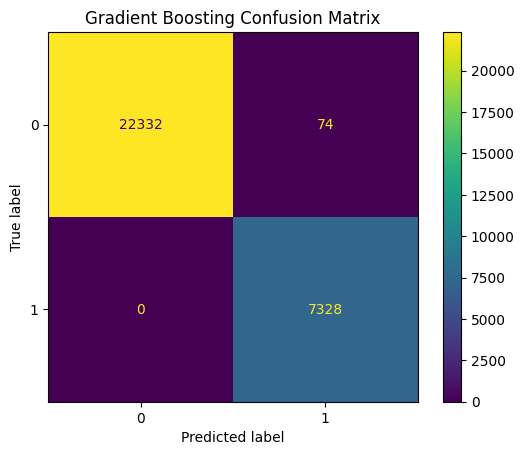


Gradient Boosting Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22406
           1       0.99      1.00      0.99      7328

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734



In [51]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Initialize model
gb = GradientBoostingClassifier(
    n_estimators=100,      # number of boosting stages (trees)
    learning_rate=0.1,     # shrinkage factor
    max_depth=3,           # depth of individual trees (weak learners)
    random_state=None
)

# Train
gb.fit(X_train, y_train)

# Predict
y_pred_gb = gb.predict(X_test)

# Confusion matrix
cm_gb = confusion_matrix(y_test, y_pred_gb)
print("Gradient Boosting Confusion Matrix:\n", cm_gb)

# Visualize
ConfusionMatrixDisplay(confusion_matrix=cm_gb).plot()
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

# Evaluation
print("\nGradient Boosting Classification Report:\n")
print(classification_report(y_test, y_pred_gb))